In [1]:
import random

In [2]:
import pandas as pd
import os
print(os.getcwd())
df=pd.read_csv('bank-full.csv',sep=';')
df.head()
print(df['y'].unique())

C:\Users\ACER\Desktop\python--learning
['no' 'yes']


In [13]:
df=pd.get_dummies(df, columns=['job', 'marital', 'education', 'housing', 'loan'])

In [14]:
df.head()

,age,default,balance,contact,day,month,duration,campaign,pdays,previous,...,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,housing_no,housing_yes,loan_no,loan_yes
0,58,no,2143,unknown,5,may,261,1,-1,0,...,True,False,False,False,True,False,False,True,True,False
1,44,no,29,unknown,5,may,151,1,-1,0,...,False,True,False,True,False,False,False,True,True,False
2,33,no,2,unknown,5,may,76,1,-1,0,...,True,False,False,True,False,False,False,True,False,True
3,47,no,1506,unknown,5,may,92,1,-1,0,...,True,False,False,False,False,True,False,True,True,False
4,33,no,1,unknown,5,may,198,1,-1,0,...,False,True,False,False,False,True,True,False,True,False


In [17]:
df = df.drop(columns=['duration'])

In [18]:
df.head()

,age,default,balance,contact,day,month,campaign,pdays,previous,poutcome,...,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,housing_no,housing_yes,loan_no,loan_yes
0,58,no,2143,unknown,5,may,1,-1,0,unknown,...,True,False,False,False,True,False,False,True,True,False
1,44,no,29,unknown,5,may,1,-1,0,unknown,...,False,True,False,True,False,False,False,True,True,False
2,33,no,2,unknown,5,may,1,-1,0,unknown,...,True,False,False,True,False,False,False,True,False,True
3,47,no,1506,unknown,5,may,1,-1,0,unknown,...,True,False,False,False,False,True,False,True,True,False
4,33,no,1,unknown,5,may,1,-1,0,unknown,...,False,True,False,False,False,True,True,False,True,False


In [4]:
df['y_binary']=df['y'].map({'yes':1, 'no':0})

In [11]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_binary
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


In [13]:
df.groupby(['job','education'])['y_binary'].mean().reset_index()

,job,education,y_binary
0,admin.,primary,0.057416
1,admin.,secondary,0.118986
2,admin.,tertiary,0.173077
3,admin.,unknown,0.105263
4,blue-collar,primary,0.058010
5,blue-collar,secondary,0.080618
6,blue-collar,tertiary,0.161074
7,blue-collar,unknown,0.072687
8,entrepreneur,primary,0.065574
9,entrepreneur,secondary,0.095941


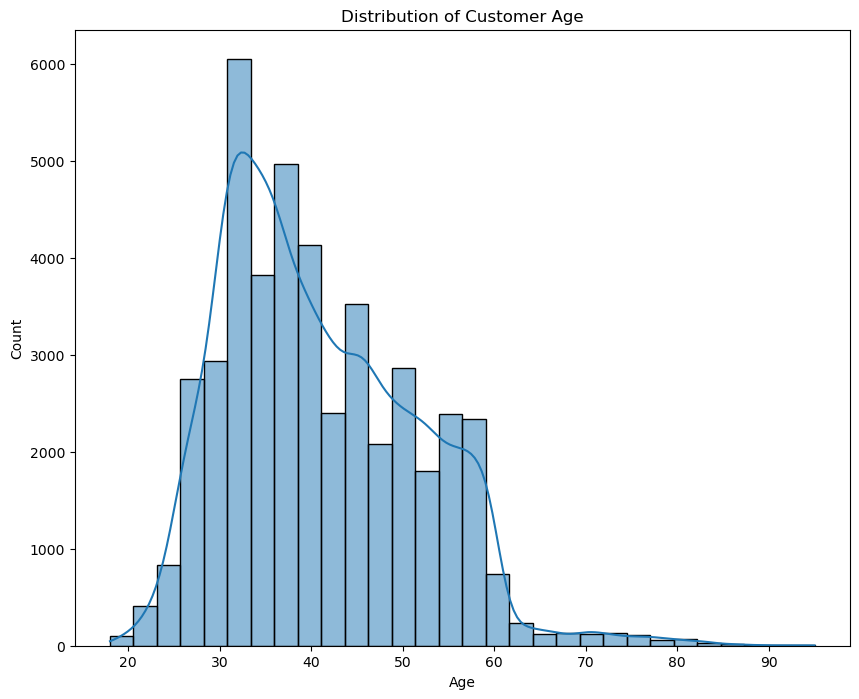

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
#plot for customer age
plt.figure(figsize=(10,8))
sns.histplot(df['age'], kde=True, bins=30)
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

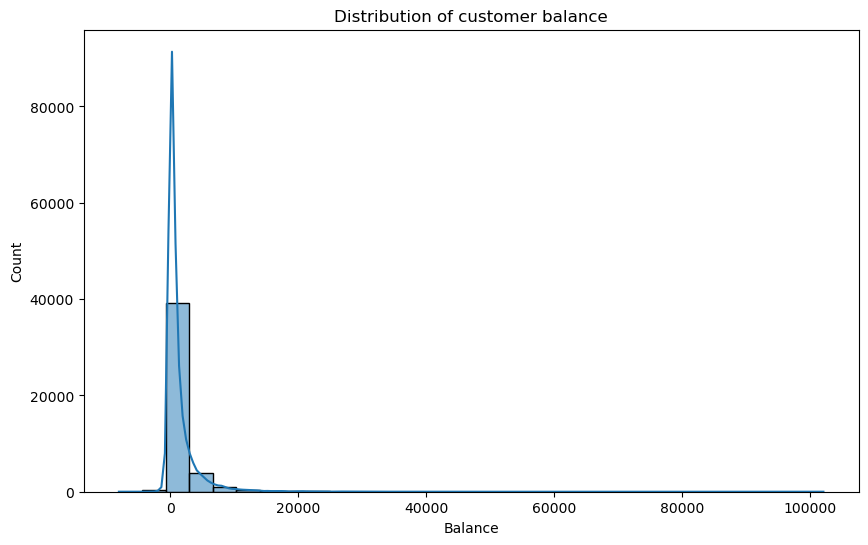

In [16]:
#plot for customer balance
plt.figure(figsize=(10,6))
sns.histplot(df["balance"], kde=True, bins=30)
plt.title("Distribution of customer balance")
plt.xlabel("Balance")
plt.ylabel("Count")
plt.show()
    

C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


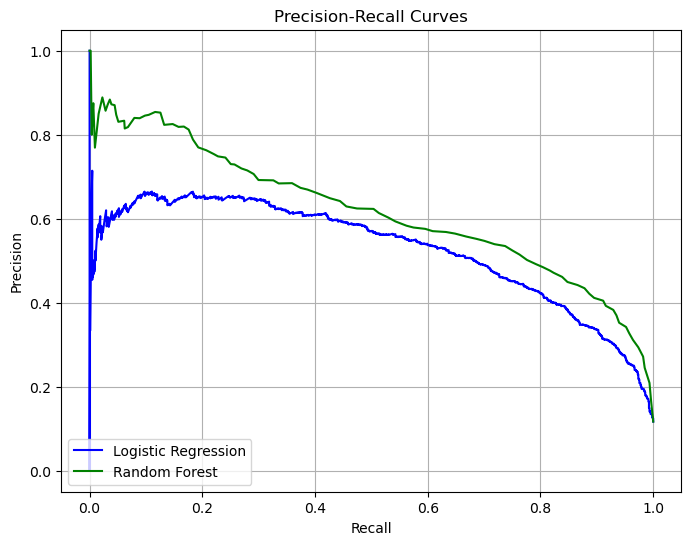

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_curve
from sklearn.model_selection import train_test_split

#split the data(80% train, 20% test with stratification)
#define x(feature bu droping the the original and converted target columns
X= df.drop(columns=["y", "y_binary"])
#define y (target variable using your binary column)
y=df["y_binary"]

X=pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

#train logisticregression baseline(handling class imbalance)
log_reg= LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

#train RandomForestclassifier ( handling class imbalances)
rf_clf= RandomForestClassifier(class_weight="balanced", random_state=42)
rf_clf.fit(X_train, y_train)

#predict possibilities for precision-recall evaluatiom
y_scores_log=log_reg.predict_proba(X_test)[:,1]
y_scores_rf=rf_clf.predict_proba(X_test)[:,1]

#compute precion recall curves
precision_log, recall_log, _= precision_recall_curve(y_test, y_scores_log)
precision_rf, recall_rf, _= precision_recall_curve(y_test, y_scores_rf)

import matplotlib.pyplot as plt
#set up the plot size

plt.figure(figsize=(8,6))

#plot Logistic regression
plt.plot(recall_log, precision_log, label='Logistic Regression', color='blue')
#plot Random forest
plt.plot(recall_rf, precision_rf, label='Random Forest', color='green')

#add label, title and legend
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


